# Chapter 45: Principal Component Analysis

Principal Component Analysis (PCA) is an unsupervised technique broadly used in the preprocessing of data to reduce dimensionality, filter through noise, extract feature and provide visualization.

Begin with the standard imports:

In [75]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Introducing PCA

PCA is a fast and flexible method for dimensionality reduction. Consider the following dataset:

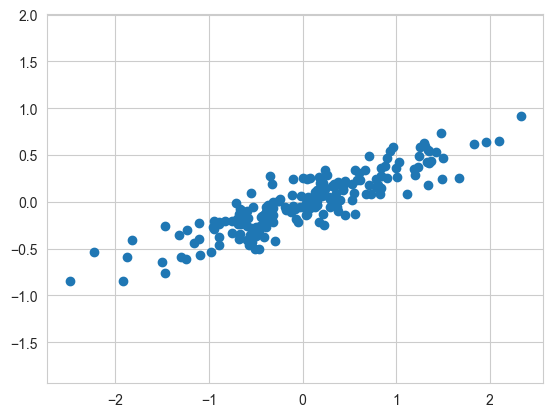

In [76]:
rng = np.random.RandomState(1)
X = np.dot(rng.rand(2, 2), rng.randn(2, 200)).T
plt.scatter(X[:, 0], X[:, 1])
plt.axis('equal');

Upon inspection, one can notice a linear relation between variables x and y. The goal of PCA is to find the principal axes in the data, and use those to describe the dataset.
PCA considers that the directions where most of the variance is found are the most relevant ones.

Scikit-Learn implements a `PCA` estimator:


In [77]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


Let us look at the learned parameters:

In [78]:
print(pca.components_)

[[ 0.94446029  0.32862557]
 [-0.32862557  0.94446029]]


In [79]:
print(pca.explained_variance_)

[0.7625315 0.0184779]


The following helper function allows us to visualize the PCA components as vectors:

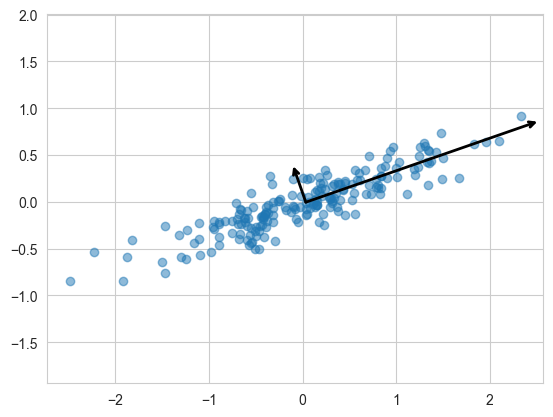

In [80]:
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->', linewidth=2, color='black',
                    shrinkA=0, shrinkB=0)
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
plt.axis('equal');

PCA performs an _affine transformation_ of the data, which means it performs translation, rotation and uniform scaling.

Let us look at the data after applying the PCA from above:

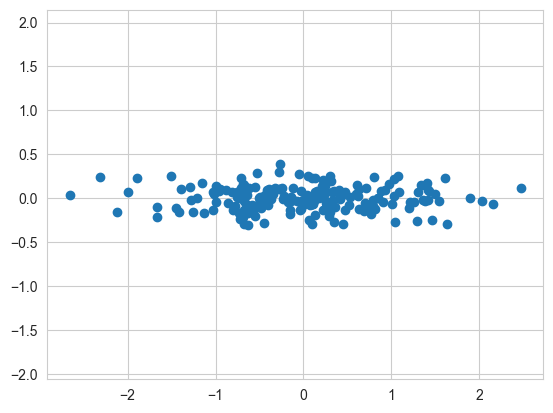

In [81]:
X_pca = pca.transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.axis('equal');

Notice how the data has been rotated. Translation and scaling did not take place due to the nature of the training data. We can set PCA to remove any correlation between variables by using a _whitening transformation_ using the `whiten` parameter when instantiaing a PCA object:

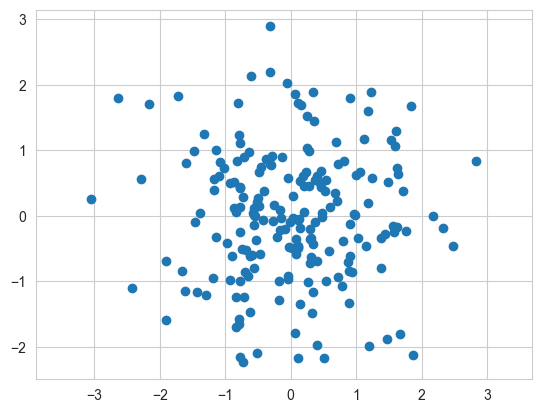

In [82]:
pca = PCA(n_components=2, whiten=True)
pca.fit(X)
X_pca = pca.transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.axis('equal');

In [83]:
print(pca.explained_variance_)

[0.7625315 0.0184779]


# PCA as Dimensionality Reduction

Using PCA for dimensionality reduction involves removing one or more of the smallest principal components. In other words, we choose only the components that preserve maximal data variance.

In [84]:
pca = PCA(n_components=1)
pca.fit(X)
X_pca = pca.transform(X)
print("original shape:   ", X.shape)
print("transformed shape:", X_pca.shape)

original shape:    (200, 2)
transformed shape: (200, 1)


The transformed data has been reduced to a single dimension. To understand the effect of this dimensionality reduction, we can perform the _inverse transform_ of the reduced data and plot it alongside the original data:

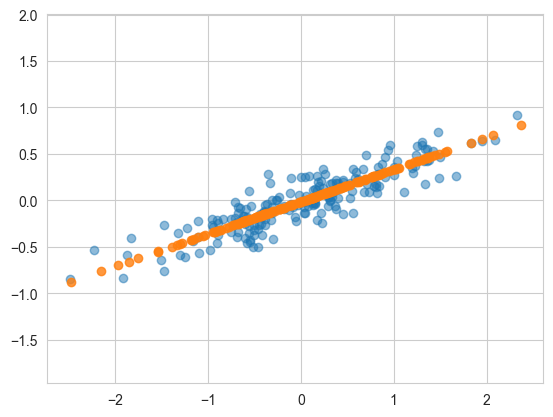

In [85]:
X_new = pca.inverse_transform(X_pca)
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.scatter(X_new[:, 0], X_new[:, 1], alpha=0.8)
plt.axis('equal');

# PCA for Visualization: Handwritten Digits

Let us use PCA to visualize important features in the Handwritten digits dataset.

In [86]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

Recall that these are $8 \times 8$-pixel images, or 64-dimensional input vectors.
Using PCA, we can project these 64 features into a smaller number of dimensions, for instance, two:

In [89]:
pca = PCA(2)  # project from 64 to 2 dimensions
projected = pca.fit_transform(digits.data)
print(digits.data.shape)
print(projected.shape)

(1797, 64)
(1797, 2)


Since the data is now in two dimensions, we can easily plot it:

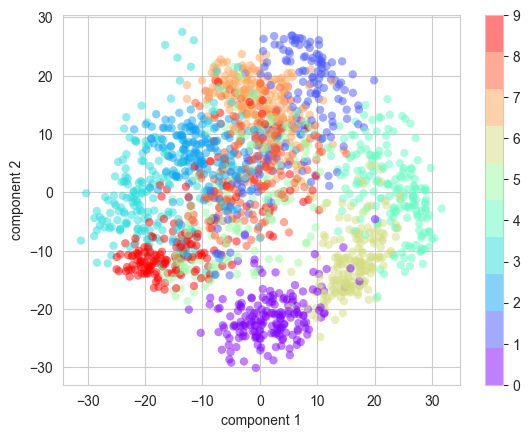

In [88]:
plt.scatter(projected[:, 0], projected[:, 1],
                     c=digits.target, edgecolor='none', alpha=0.5,
                     cmap=plt.get_cmap('rainbow', 10))
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.colorbar();

# What do the components mean?

Each image is a collection of 64 pixels:

$$ x = [x_1, x_2, x_3,...,x_{64}]$$

One way to think of this is to construct a _pixel basis_.

$$image(x) = x_1(pixel 1) + x_2(pixel 2) + ... x_{64}(pixel 64)$$

A naive way to reduce dimensionality is to zero out all but a few of these basis vectors (likely the most important ones). For instance, if we use only the first eight pixels, we get an eight-dimensional projection of the data. This is not a good idea because we've thrown out 90% of the pixels!

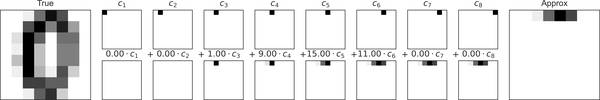

Instead of a pixel-wise representation, we can use other basis functions that consist of a predefined contribution from each pixel, something like:

$$image(x) = mean + x_1 \cdot (basis 1) + x_2 \cdot (basis 2) +...$$



PCA can be thought of as a process of choosing the optimal basis function, such that adding together just the first few is enough to reconstruct the bulk of the elements in the dataset (based on the variance).

A more sophisticated dimensionality reduction using PCA would look like:

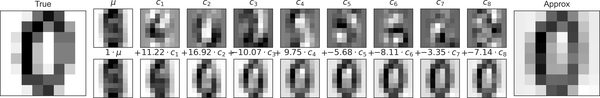

# Choosing the number of components

To determine how many components to use, one can look at the _explained variance ratio_ as a fraction of the number of components:

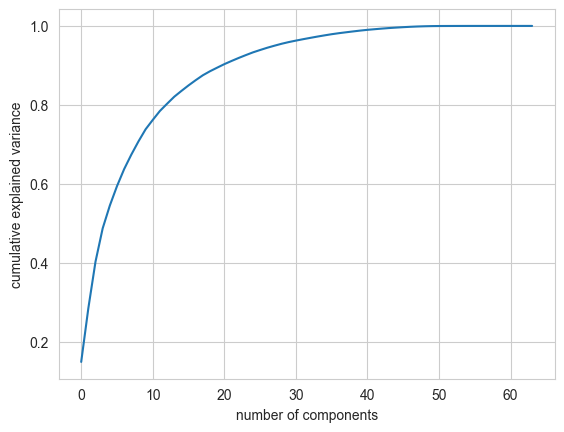

In [90]:
pca = PCA().fit(digits.data)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

Notice that the first 10 components explain approximately 75% of the variance, the top 20 components explain 90% of the variance. With 50 components we get close to 100% of the variance.

This visualization provides insight into the redundancy present in the input features.

# Example: Eigenfaces

In a previous lab, we used PCA to determine reduce the dimensionality of the Labeled Faces in the Wild (LFW) dataset.

In [91]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


Let us take a look at the principal axes that span this dataset. Because the dataset is large, we will use a "random" eigensolver, which sacrifices a little accuracy for faster running times.

In [93]:
pca = PCA(150, svd_solver='randomized', random_state=42)
pca.fit(faces.data)

,n_components,150
,copy,True
,whiten,False
,svd_solver,'randomized'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


We will now visualize the images associated with the first several principal components (eigenvectors, or _eigenfaces_ in these types of images). The results are as creepy as thei sound:

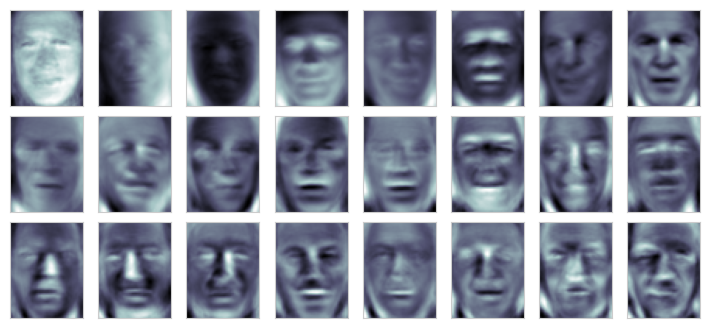

In [94]:
fig, axes = plt.subplots(3, 8, figsize=(9, 4),
                                  subplot_kw={'xticks':[], 'yticks':[]},
                                  gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(62, 47), cmap='bone')

These results give us insight into how the images vary: the first few eigenfaces seem to be associated with the angle of lighting on the face, later principal vectors seem to be picking out certain features, such as eyes, noses, and lips.

Let us look at the cumulative variance of these components:

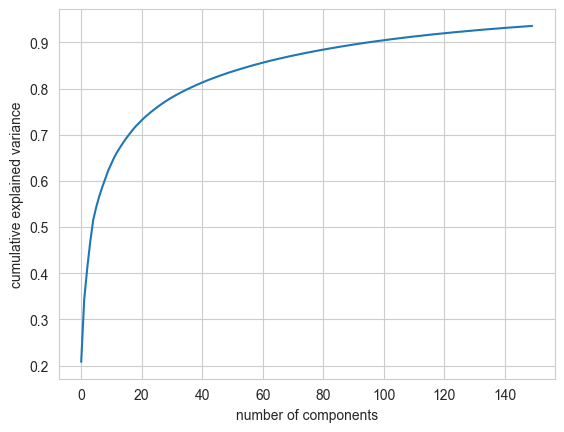

In [95]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

Using the 150 components accounts for over 90% of the variance.
This indicates that our chosen components captures the essential characteristics of the data.

__How many features are there in a 62 x 47 image?__

To make this more concrete, we can compare the input images with images reconstructed from these 150 components:

In [97]:
pca = pca.fit(faces.data)
components = pca.transform(faces.data)
projected = pca.inverse_transform(components)

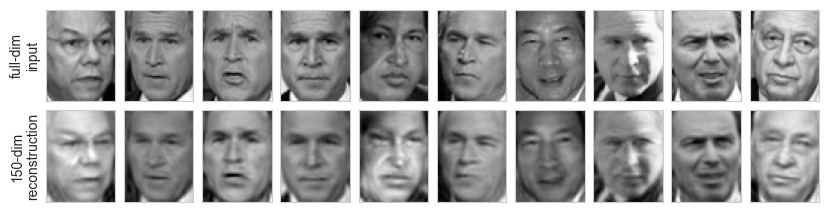

In [98]:
fig, ax = plt.subplots(2, 10, figsize=(10, 2.5),
                                subplot_kw={'xticks':[], 'yticks':[]},
                                gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i in range(10):
    ax[0, i].imshow(faces.data[i].reshape(62, 47), cmap='binary_r')
    ax[1, i].imshow(projected[i].reshape(62, 47), cmap='binary_r')

ax[0, 0].set_ylabel('full-dim\ninput')
ax[1, 0].set_ylabel('150-dim\nreconstruction');

Top row shows the input images with about 3,000 features, bottom row shows the reduced 150 features. Despite reducing dimensionality by a factor of 20, the projected images contain enough information to recognize the individuals in each image.

# Chapter 46: Manifold Learning

We just saw that PCA can be used as a fast and easily interpretable method for dimensionality reduction.
However, PCA does not perform well when there are nonlinear relationships within the data.

To address its deficiency, we turn to _manifold learning algorithms_, a class of unsupervised estimators that seek to describe datasets as low-dimensional manifolds embedded in high-dimensional spaces. 

As a manifold, imagine a sheet of paper: a two-dimensional object that lives in our familiar three-dimensional world.
Rotating, reorienting or stretching the piece of paper in three-dimensional space does not change its flat geometry: such operations are akin to linear embeddings.
If you bend, curl, or crumple the paper, it is still a two-dimensional manifold, but the embedding into three-dimensional space is no longer linear.
Manifold learning algorithms seek to learn about the fundamental two-dimensional nature of the paper, even as it is contorted to fill the three-dimensional space.

Beginning with standard imports:

In [99]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

Let us generate some data. The following function will produce points in the shape of the world "HELLO":

In [100]:
def make_hello(N=1000, rseed=42):
            # Make a plot with "HELLO" text; save as PNG
            fig, ax = plt.subplots(figsize=(4, 1))
            fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
            ax.axis('off')
            ax.text(0.5, 0.4, 'HELLO', va='center', ha='center',
                    weight='bold', size=85)
            fig.savefig('hello.png')
            plt.close(fig)

            # Open this PNG and draw random points from it
            from matplotlib.image import imread
            data = imread('hello.png')[::-1, :, 0].T
            rng = np.random.RandomState(rseed)
            X = rng.rand(4 * N, 2)
            i, j = (X * data.shape).astype(int).T
            mask = (data[i, j] < 1)
            X = X[mask]
            X[:, 0] *= (data.shape[0] / data.shape[1])
            X = X[:N]
            return X[np.argsort(X[:, 0])]

Visualizing:

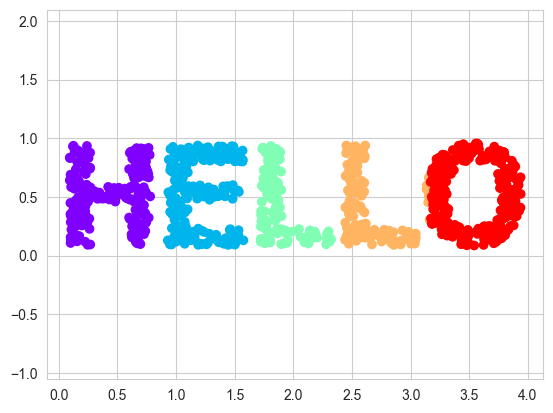

In [101]:
X = make_hello(1000)
colorize = dict(c=X[:, 0], cmap=plt.get_cmap('rainbow', 5))
plt.scatter(X[:, 0], X[:, 1], **colorize)
plt.axis('equal');

Looking at this data, we can see that the choice of _x_ and _y_ coordinates are not the most fundamental description of the data. For example, if we rotate the matrix, the data is still fundamentally the same:

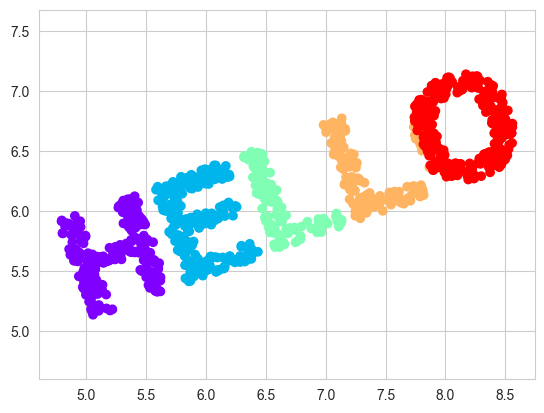

In [102]:
def rotate(X, angle):
    theta = np.deg2rad(angle)
    R = [[np.cos(theta), np.sin(theta)],
            [-np.sin(theta), np.cos(theta)]]
    return np.dot(X, R)

X2 = rotate(X, 20) + 5
plt.scatter(X2[:, 0], X2[:, 1], **colorize)
plt.axis('equal');

Fundamentally, the _distance_ between each point is what contributes to describing the data.
A common way to represent this is to use a _distance matrix_: for $N$ points, we construct an $N \times N$ matrix such that $(i,j)$ contains the distance between point $i$ and point $j$.

In Scikit-Learn, we can do this with `pairwise_distances`:

In [103]:
from sklearn.metrics import pairwise_distances
D = pairwise_distances(X)
D.shape

(1000, 1000)

Visualizing the distribution of distances:

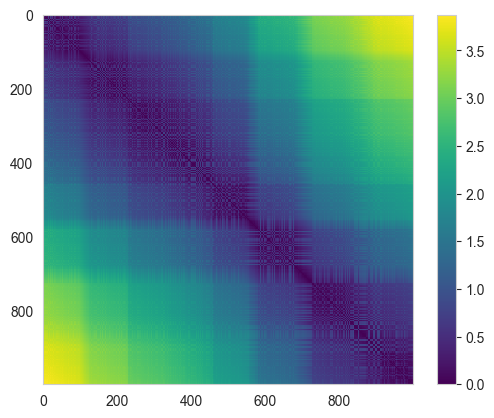

In [104]:
plt.imshow(D, zorder=2, cmap='viridis', interpolation='nearest')
plt.colorbar();

Computing the distance matrix $D$ is straightforward. What is more complicated is transforming the distances back into _x_ and _y_ coordinates.
This is exactly what __multidimensional scaling (MDS)__ does: given a distance matrix between points, it recovers a $D$-dimensional coordinate representation of the data:

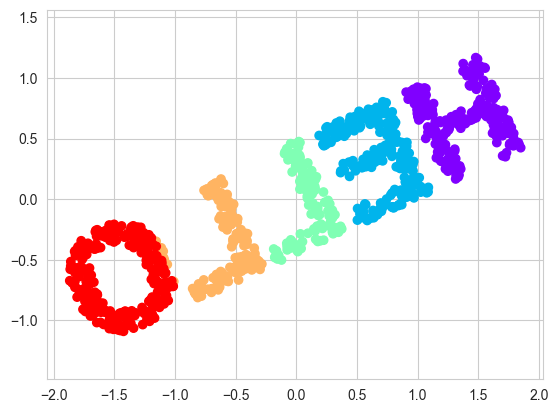

In [105]:
from sklearn.manifold import MDS
model = MDS(n_components=2, dissimilarity='precomputed', random_state=1701, n_init=4)
out = model.fit_transform(D)
plt.scatter(out[:, 0], out[:, 1], **colorize)
plt.axis('equal');

The MDS algorithm recovered one of the possible two-dimensional coordinate representations of our data using only the $N \times N$ distance matrix describing the relationship between the data points.

# MDS as Manifold Learning

The usefulness of manifold learning becomes more apparent when we consider that distance matrices can be computed from data in _any dimension_. For example, consider the projection of our "HELLO" dataset into three dimensions:

In [106]:
def random_projection(X, dimension=3, rseed=42):
            assert dimension >= X.shape[1]
            rng = np.random.RandomState(rseed)
            C = rng.randn(dimension, dimension)
            e, V = np.linalg.eigh(np.dot(C, C.T))
            return np.dot(X, V[:X.shape[1]])

X3 = random_projection(X, 3)
X3.shape

(1000, 3)

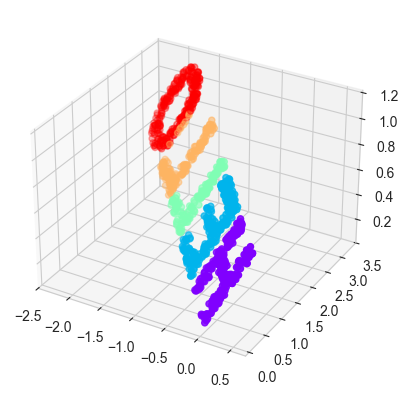

In [107]:
from mpl_toolkits import mplot3d
ax = plt.axes(projection='3d')
ax.scatter3D(X3[:, 0], X3[:, 1], X3[:, 2],
            **colorize);

Just like a 2D sheet of paper in our 3D world, MDS can easily learn the representation of this dataset into two dimensions:

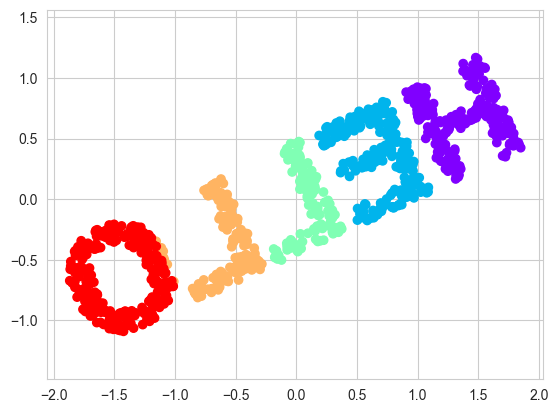

In [108]:
model = MDS(n_components=2, random_state=1701, n_init=4)
out3 = model.fit_transform(X3)
plt.scatter(out3[:, 0], out3[:, 1], **colorize)
plt.axis('equal');

# Nonlinear Embeddings: Where MDS fails

So far, we have considered _linear_ embeddings, which essentially consist of rotations, translations and scalings of data.
MDS breaks down when the embedding is nonlinear. For example, consider the following transformation that contorts "HELLO" into an "S" shape in 3D:

In [109]:
def make_hello_s_curve(X):
             t = (X[:, 0] - 2) * 0.75 * np.pi
             x = np.sin(t)
             y = X[:, 1]
             z = np.sign(t) * (np.cos(t) - 1)
             return np.vstack((x, y, z)).T

XS = make_hello_s_curve(X)

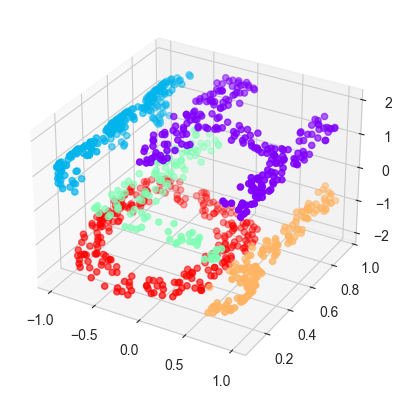

In [110]:
from mpl_toolkits import mplot3d
ax = plt.axes(projection='3d')
ax.scatter3D(XS[:, 0], XS[:, 1], XS[:, 2],
            **colorize);

If we attempt to apply MDS on this data, it will not be able to "unwrap" the nonlinear relationship.

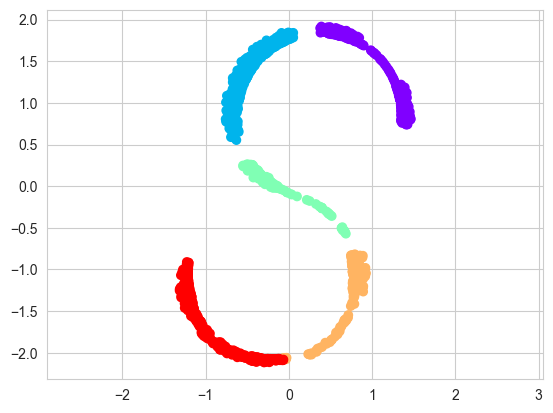

In [111]:
from sklearn.manifold import MDS
model = MDS(n_components=2, random_state=2, n_init=4)
outS = model.fit_transform(XS)
plt.scatter(outS[:, 0], outS[:, 1], **colorize)
plt.axis('equal');

# Nonliner Manifolds: Locally Linear Embedding

Locally Linear Embedding (LLE) tries to preserve only the distances to its nearest neighboring points, instead of all the points. The following shows a comparison between distances in MDS and LLE:
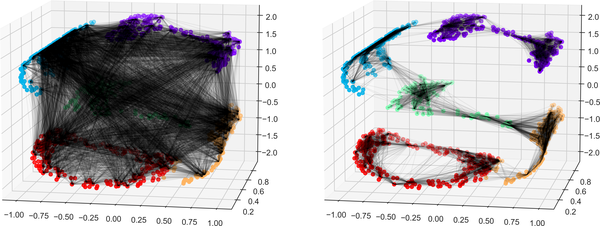


We can use LLE to recover the structure of our S-shaped data and project it to two dimensions:

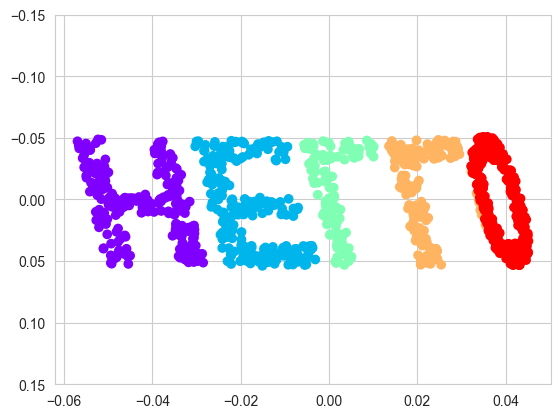

In [112]:
from sklearn.manifold import LocallyLinearEmbedding
model = LocallyLinearEmbedding(
    n_neighbors=100, n_components=2,
    method='modified', eigen_solver='dense')
out = model.fit_transform(XS)

fig, ax = plt.subplots()
ax.scatter(out[:, 0], out[:, 1], **colorize)
ax.set_ylim(0.15, -0.15);

A few notes on manifold learning:
- While PCA naturally filters noise, manifold learning may not handle noise well.
- The manifold embedding result is highly dependent on hyperparameters, such as the number of neighbors chosen in LLE. In contrast, PCA does not involve such a choice.
- The optimal number of dimensions is difficult to determine in manifold learning. PCA allows you to find the number of outputs based on the explained variance.
- In manifold learning, the _meaning_ of embedded dimensions is not always clear. In PCA, the principal components have a very clear meaning.
- Manifold learning methods run in $O(N^2)$ or $O(N^3)$. For PCA, there are fast randomized approaches.

# Chapter 47: K-means clustering

Clustering algorithms are another class of unsupervised machine learning models.
These algorithms seek to learn an optimal division of the data into groups of points.

# Introducing K-means

The k-means algorithm searches for a predetermined number of clusters within an unlabeled dataset.
It accomplishes this using a simple conception of what the optimal clustering looks like:
- The _cluster center_ is the arithmetic mean of all the points belonging to the cluster.
- Each point is closer to its own cluster center than to other cluster centers.

These two assumptions are the basis of the k-means model.

Generating some data:

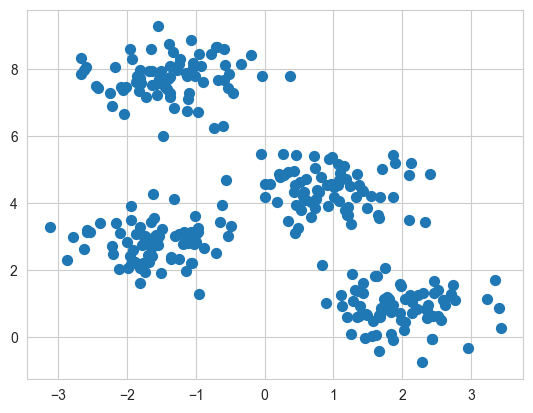

In [113]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                        cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

By eye, we can pick out the four clusters. The k-means algorithm does that automatically:

In [114]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

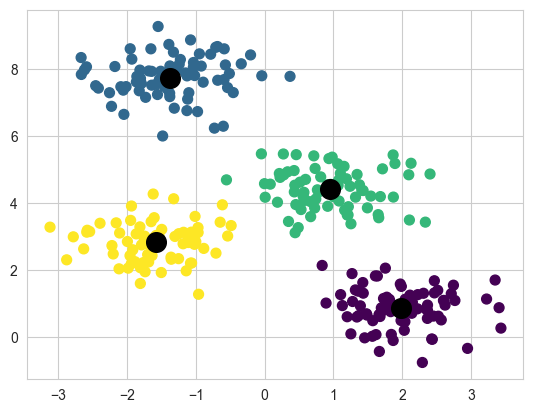

In [115]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200);

## Expectation-Maximization

The k-means algorithm implements an expectation-maximization (E-M) procedure:

1. Guess some cluster centers.
2. Repeat until converged:
    1.   E-step: Assign points to the nearest cluster center.
    2.   M-step: Set the cluster centers to the mean of their assignment points.

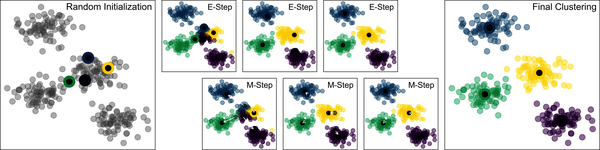